In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score, recall_score,f1_score
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
%matplotlib inline

In [2]:
#Reads and previews the initial 10 rows of a 'Lung Cancer.csv' dataset using Pandas
df=pd.read_csv('Lung Cancer.csv')
df.head(10)

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO
5,F,75,1,2,1,1,2,2,2,2,1,2,2,1,1,YES
6,M,52,2,1,1,1,1,2,1,2,2,2,2,1,2,YES
7,F,51,2,2,2,2,1,2,2,1,1,1,2,2,1,YES
8,F,68,2,1,2,1,1,2,1,1,1,1,1,1,1,NO
9,M,53,2,2,2,2,2,1,2,1,2,1,1,2,2,YES


In [3]:
#Data pre processing: It involves cleaning, transforming, and organizing raw data to prepare it for analysis or model 

In [3]:
df.shape

(309, 16)

In [4]:
df=df.dropna()

In [5]:
df.shape

(309, 16)

In [6]:
df.describe()

,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,62.673139,1.563107,1.569579,1.498382,1.501618,1.504854,1.673139,1.556634,1.556634,1.556634,1.579288,1.640777,1.469256,1.556634
std,8.210301,0.496806,0.495938,0.500808,0.500808,0.500787,0.469827,0.497588,0.497588,0.497588,0.494474,0.480551,0.499863,0.497588
min,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,57.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,62.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000
75%,69.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,87.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [7]:
df=df.drop_duplicates()

In [8]:
df.shape

(276, 16)

In [9]:
df.head(10)

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO
5,F,75,1,2,1,1,2,2,2,2,1,2,2,1,1,YES
6,M,52,2,1,1,1,1,2,1,2,2,2,2,1,2,YES
7,F,51,2,2,2,2,1,2,2,1,1,1,2,2,1,YES
8,F,68,2,1,2,1,1,2,1,1,1,1,1,1,1,NO
9,M,53,2,2,2,2,2,1,2,1,2,1,1,2,2,YES


In [ ]:
#A boxplot displays the distribution of a numerical variable, showing its median, quartiles, and potential outliers, 
#offering insights into the data's spread and central tendency
sns.boxplot(df['AGE'])

In [11]:
#Removing outliers
#Identifies and extracts outliers in the 'AGE' column using the interquartile range (IQR) method
df_age=df['AGE']
q3=df_age.quantile(0.75)
q1=df_age.quantile(0.25)
iqr=q3-q1
ll=q1-(1.5*iqr)
ul=q3+(1.5*iqr)
age_outliers = df_age[(df_age<ll) | (df_age>ul)]

In [12]:
(age_outliers)

22     21
238    38
261    39
277    87
Name: AGE, dtype: int64

In [13]:
outlier=[22,238,261,277]

In [14]:
df.drop(index=outlier, inplace= True)

In [15]:
df.columns

Index(['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY',
       'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING',
       'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH',
       'SWALLOWING DIFFICULTY', 'CHEST PAIN', 'LUNG_CANCER'],
      dtype='object')

In [16]:
df.shape

(272, 16)

In [17]:
#Label encoding transforms categorical data into numerical format by assigning a unique numeric label to each category
le=LabelEncoder()
df['LUNG_CANCER']=le.fit_transform(df['LUNG_CANCER'])
df['GENDER']=le.fit_transform(df['GENDER'])

In [18]:
df['LUNG_CANCER'].head(10)

0    1
1    1
2    0
3    0
4    0
5    1
6    1
7    1
8    0
9    1
Name: LUNG_CANCER, dtype: int32

In [19]:
df['LUNG_CANCER'].value_counts()

1    236
0     36
Name: LUNG_CANCER, dtype: int64

In [ ]:
sns.countplot(df['LUNG_CANCER'])#Plots counts of categorical values

In [21]:
df1=df.drop('AGE',axis=1)

In [22]:
dict1={}

In [23]:
#Calculates chi-square statistics for each column in df1 related to 'LUNG_CANCER' and prints the results, storing 
#chi-square values in dict1.

#Chi-square test assesses independence between categorical variables by comparing observed and expected frequencies in 
#a contingency table.
for column in df1.columns:
    table=pd.crosstab(df[column],df['LUNG_CANCER'])
    chi2,_, _, _ = chi2_contingency(table)
    print(f"Chi-square statistic for {column}: {chi2}")
    dict1[column]=chi2

Chi-square statistic for GENDER: 0.17307652113288746
Chi-square statistic for SMOKING: 0.15284612113480403
Chi-square statistic for YELLOW_FINGERS: 7.223929809505527
Chi-square statistic for ANXIETY: 4.0627265780083075
Chi-square statistic for PEER_PRESSURE: 7.990179081406724
Chi-square statistic for CHRONIC DISEASE: 6.57721285700463
Chi-square statistic for FATIGUE : 7.357937960013153
Chi-square statistic for ALLERGY : 29.382294268024182
Chi-square statistic for WHEEZING: 13.500585769896674
Chi-square statistic for ALCOHOL CONSUMING: 20.208191363733764
Chi-square statistic for COUGHING: 14.25538529868976
Chi-square statistic for SHORTNESS OF BREATH: 1.2293785310734462
Chi-square statistic for SWALLOWING DIFFICULTY: 17.19879816529403
Chi-square statistic for CHEST PAIN: 7.535447847490667
Chi-square statistic for LUNG_CANCER: 263.36159965385286


In [24]:
#Creates age groups categorization.
#Bins are predefined intervals in data
bins = [44, 60, 81] 
labels = ['44-60', '61-81'] # Label assigned to each bin
df['AGE_group'] = pd.cut(df['AGE'], bins=bins, labels=labels)

In [25]:
#Prints chi-square summary for age groups' association with lung cancer, storing chi-square value in `dict1['AGE_group']`.
#A contingency table summarizes the distribution of categorical variables, showcasing their joint occurrences.
contingency_table = pd.crosstab(df['AGE_group'], df['LUNG_CANCER'])
print(contingency_table)
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(chi2)
dict1['AGE_group']=chi2

LUNG_CANCER   0    1
AGE_group           
44-60        18   85
61-81        18  149
1.927230304141531


In [26]:
#Sorts dictionary by values descendingly
sorted_dict=sorted(dict1.items(),key=lambda item: item[1],reverse=True)
sorted_dict

[('LUNG_CANCER', 263.36159965385286),
 ('ALLERGY ', 29.382294268024182),
 ('ALCOHOL CONSUMING', 20.208191363733764),
 ('SWALLOWING DIFFICULTY', 17.19879816529403),
 ('COUGHING', 14.25538529868976),
 ('WHEEZING', 13.500585769896674),
 ('PEER_PRESSURE', 7.990179081406724),
 ('CHEST PAIN', 7.535447847490667),
 ('FATIGUE ', 7.357937960013153),
 ('YELLOW_FINGERS', 7.223929809505527),
 ('CHRONIC DISEASE', 6.57721285700463),
 ('ANXIETY', 4.0627265780083075),
 ('AGE_group', 1.927230304141531),
 ('SHORTNESS OF BREATH', 1.2293785310734462),
 ('GENDER', 0.17307652113288746),
 ('SMOKING', 0.15284612113480403)]

In [27]:
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER,AGE_group
0,1,69,1,2,2,1,1,2,1,2,2,2,2,2,2,1,61-81
1,1,74,2,1,1,1,2,2,2,1,1,1,2,2,2,1,61-81
2,0,59,1,1,1,2,1,2,1,2,1,2,2,1,2,0,44-60
3,1,63,2,2,2,1,1,1,1,1,2,1,1,2,2,0,61-81
4,0,63,1,2,1,1,1,1,1,2,1,2,2,1,1,0,61-81


In [28]:
x=df.drop(['SMOKING','GENDER','SHORTNESS OF BREATH','AGE','CHRONIC DISEASE','ANXIETY','AGE_group','LUNG_CANCER','YELLOW_FINGERS','FATIGUE '],axis=1)

In [29]:
y=df['LUNG_CANCER']

In [30]:
x

,PEER_PRESSURE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SWALLOWING DIFFICULTY,CHEST PAIN
0,1,1,2,2,2,2,2
1,1,2,1,1,1,2,2
2,2,1,2,1,2,1,2
3,1,1,1,2,1,2,2
4,1,1,2,1,2,1,1
...,...,...,...,...,...,...,...
279,2,2,2,1,2,2,1
280,1,2,1,1,1,1,1
281,1,2,1,1,1,1,2
282,1,1,1,1,1,2,2


In [31]:
y

0      1
1      1
2      0
3      0
4      0
      ..
279    1
280    0
281    0
282    0
283    1
Name: LUNG_CANCER, Length: 272, dtype: int32

In [32]:
#Balances classes using SMOTE technique, displaying new class distribution.
#SMOTE creates synthetic samples to balance class distribution in machine learning datasets
smote=SMOTE(random_state=42)
x,y=smote.fit_resample(x,y)
y.value_counts()

1    236
0    236
Name: LUNG_CANCER, dtype: int64

In [33]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [ ]:
#Logistic Regression:It predicts binary outcomes by modeling the relationship between independent 
#variables and the probability of a particular event

In [ ]:
sns.countplot(y)

In [36]:
model=LogisticRegression()

In [37]:
model.fit(x_train,y_train)

LogisticRegression()

In [38]:
#Checking for overfitting
train_accuracy = model.score(x_train, y_train)
val_accuracy = model.score(x_test, y_test)
print(train_accuracy)
print(val_accuracy)
#No overfitting since these values are close

0.9212121212121213
0.9225352112676056


In [39]:
y_pred=model.predict(x_test)

In [40]:
#Calculates the accuracy of predictions on the test set by comparing them to the actual labels.
#Accuracy Score Formula= {Number of Correct Predictions}\{Total Number of Predictions}
accuracy=accuracy_score(y_test,y_pred)

In [41]:
print(accuracy)

0.9225352112676056


In [42]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

metrics_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [accuracy, precision, recall, f1]
})


In [43]:
#Confusion matrix is a table showing the performance of a classification model, summarizing true positive, true negative, 
#false positive, and false negative values
cm=confusion_matrix(y_test,y_pred)

<AxesSubplot: >

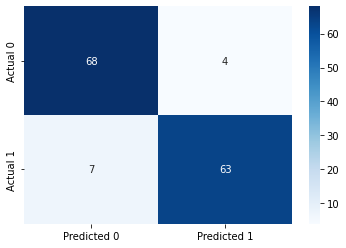

In [44]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])

In [45]:
print(metrics_table)

      Metric     Score
0   Accuracy  0.922535
1  Precision  0.940299
2     Recall  0.900000
3   F1 Score  0.919708


In [ ]:
#K nearest neighbors:It is a supervised machine learning algorithm that classifies a data point based on the majority 
#class of its k-nearest neighbors in the feature space.
#The Euclidean distance formula is commonly used to measure the distance between data points in K Nearest Neighbors. 
#For two points (x_1, y_1) and (x_2, y_2), the Euclidean distance ((d)) is calculated as

In [46]:
# Fits a K Nearest Neighbors classifier with \(k=15\) on training data, predicts on the test data, and prints the accuracy 
#score.
knn=KNeighborsClassifier(n_neighbors=15)
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

0.9154929577464789


In [47]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

metrics_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [accuracy, precision, recall, f1]
})

In [48]:
cm=confusion_matrix(y_test,y_pred)

<AxesSubplot: >

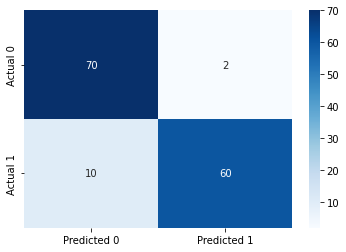

In [49]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])

In [50]:
print(metrics_table)

      Metric     Score
0   Accuracy  0.915493
1  Precision  0.967742
2     Recall  0.857143
3   F1 Score  0.909091


In [415]:
#Naive Baye's: Naive Bayes is a probabilistic classification algorithm based on Bayes' theorem, assuming independence 
#among features

In [51]:
#Fits a Gaussian Naive Bayes model on training data, predicts on the test data, and prints the accuracy score
model=GaussianNB()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

0.8802816901408451


In [52]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

metrics_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [accuracy, precision, recall, f1]
})

<AxesSubplot: >

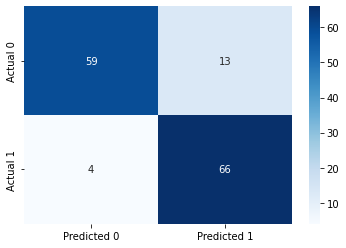

In [53]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])

In [54]:
print(metrics_table)

      Metric     Score
0   Accuracy  0.880282
1  Precision  0.835443
2     Recall  0.942857
3   F1 Score  0.885906


In [418]:
#SVM:Support Vector Machine (SVM) is a machine learning algorithm that finds the optimal hyperplane to separate data 
#into classes, maximizing the margin between them

In [55]:
model = SVC(kernel='rbf', C=1.0, gamma='scale')
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

0.9436619718309859


In [56]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

metrics_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [accuracy, precision, recall, f1]
})

<AxesSubplot: >

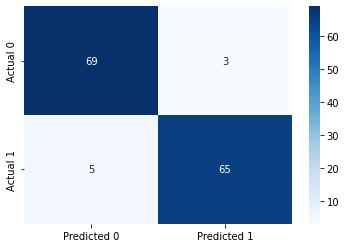

In [57]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])

In [58]:
print(metrics_table)

      Metric     Score
0   Accuracy  0.943662
1  Precision  0.955882
2     Recall  0.928571
3   F1 Score  0.942029


In [423]:
#Decision tree: A decision tree is a visual representation of choices and their possible outcomes, used for decision-making
#by following branches of criteria

In [59]:
#A decision tree classifier is created, trained on the provided training data, used to predict outcomes for test data, and 
# its accuracy is calculated and printed
model=DecisionTreeClassifier(random_state=42)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

0.9225352112676056


In [60]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

metrics_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [accuracy, precision, recall, f1]
})

<AxesSubplot: >

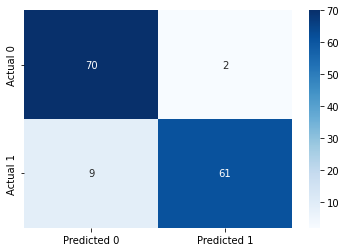

In [61]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])

In [62]:
print(metrics_table)

      Metric     Score
0   Accuracy  0.922535
1  Precision  0.968254
2     Recall  0.871429
3   F1 Score  0.917293


In [ ]:
''' Summary:

1. Data Cleaning and Exploration:
   - The dataset is loaded using Pandas and the initial 10 rows are displayed.
   - Data is cleaned by removing missing values and duplicates.
   - Outliers in the 'AGE' column are identified and removed.

2. Data Preprocessing:
   - Label encoding is applied to 'GENDER' and 'LUNG_CANCER' columns.
   - Age groups are created based on specified bins.

3. Statistical Analysis:
   - Chi-square tests are performed to assess the relationship between categorical variables and the target variable 
      ('LUNG_CANCER').
   - The statistical results are stored in a dictionary and sorted in descending order.

4. Feature Engineering:
   - The dataset is further modified by creating age groups and dropping irrelevant columns.

5. Handling Imbalanced Data:
   - Synthetic Minority Over-sampling Technique (SMOTE) is used to balance the target variable classes.

6. Train-Test Split:
   - The data is split into training and testing sets.

7. Model Training:
   - Logistic Regression, K-Nearest Neighbors (KNN), Gaussian Naive Bayes, Support Vector Machine (SVM), and Decision 
   Tree classifiers are trained on the data.

8. Model Evaluation:
   - The accuracy of each model is evaluated on the test set.
   - Confusion matrices are printed and visualized using seaborn's heatmap.

9. Conclusion/Inference:
   - The conclusion and inference depend on the performance metrics and domain knowledge.
   - The accuracy of each model on the test set is printed, and confusion matrices provide insights into model performance.

10. Parameters Used:
    - Logistic Regression, KNN, Gaussian Naive Bayes, SVM, and Decision Tree models are instantiated with default parameters.
    - For SVM, the 'rbf' kernel is used with C=1.0 and gamma='scale' parameters.
'''
